In [4]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import time

df_long_raw = pd.read_csv("df_long_clean_w_reagents_cleaned.csv")

dedupe_keys = ["source_folder", "solutionCategory", "problemCategory", "reaction_class"]
missing = [c for c in dedupe_keys if c not in df_long_raw.columns]
if missing:
    raise ValueError(f"Missing dedupe key columns: {missing}")

n_before = len(df_long_raw)
df_long = df_long_raw.drop_duplicates(subset=dedupe_keys, keep="first").copy()
n_after = len(df_long)
n_dropped = n_before - n_after

print(f"Loaded rows: {n_before:,}")
print(f"After dedupe on {dedupe_keys}: {n_after:,}")
print(f"Dropped duplicates: {n_dropped:,}")
print(df_long.columns)

print(df_long.columns)
rxn_class_list = df_long.reaction_class.unique()
rxnCategory_list = df_long.rxnCategory.unique()
rxnSubcategory_list = df_long.rxnSubcategory.unique()
problemList = df_long.problemCategory.unique()
solutionList = df_long.solutionCategory.unique()
print(f"Reaction classes: {rxn_class_list}")
print(f"Reaction categories: {rxnCategory_list}")
print(f"Reaction subcategories: {rxnSubcategory_list}")
print(f"Problem categories: {problemList}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded rows: 21,878
After dedupe on ['source_folder', 'solutionCategory', 'problemCategory', 'reaction_class']: 21,878
Dropped duplicates: 0
Index(['Unnamed: 0', 'reaction_class', 'description', 'reagents_used',
       'confidence', 'reasoning', 'pub_year', 'source_folder', 'rxnCategory',
       'rxnSubcategory', 'rxnCode', 'problemCategory', 'problemDescription',
       'solutionCategory', 'solutionDescription', 'solutionCat_L1',
       'solutionCat_L2', 'reagents_used_clean', 'n_reagents_clean'],
      dtype='object')
Index(['Unnamed: 0', 'reaction_class', 'description', 'reagents_used',
       'confidence', 'reasoning', 'pub_year', 'source_folder', 'rxnCategory',
       'rxnSubcategory', 'rxnCode', 'problemCategory', 'problemDescription',
       'solutionCategory', 'solutionDescription', 'solutionCat_L1',
       'solutionCat_L2', 'reagents_used_clean', 'n_reagents_clean'],
      dtype='object')
R

Full analysis complete: 869 rows across 94 reaction classes
Top 10 shift rows with exemplar paper/reaction:


,reaction_class,problem_category,best_year,split_score,shift_side,paper_col,paper_value,reaction_col,reaction_value,year
0,Other separation,[SOLUBILITY],2021,6.357143,before,source_folder,op500308x,None,None,2015
1,Other separation,[LOW YIELD],2020,6.300000,before,source_folder,op9b00021,None,None,2019
2,Other separation,[PURIFICATION],2021,5.714286,before,source_folder,op5b00274,None,None,2015
3,Alkene hydrogenation,[LOW YIELD],2016,5.611111,before,source_folder,op500156b,None,None,2015
4,Bromo Suzuki coupling,[PURIFICATION],2019,5.200000,before,source_folder,op9b00465,None,None,2019
5,Bromo Suzuki coupling,[VARIABILITY],2016,5.111111,before,source_folder,op5b00161,None,None,2015
6,Unrecognized,[VARIABILITY],2023,5.000000,before,source_folder,op8b00315,None,None,2018
7,Bromo Suzuki coupling,[LOW YIELD],2022,4.375000,before,source_folder,op2c00309,None,None,2022
8,Unrecognized,[COST],2022,4.000000,before,source_folder,op2c00309,None,None,2022
9,Other separation,[DECOMPOSITION],2020,3.533333,before,source_folder,op0c00168,None,None,2020



Key exemplar for the top shift:


reaction_class      Other separation
problem_category         [LOW YIELD]
best_year                       2020
shift_side                    before
split_score                      6.3
paper_col              source_folder
paper_value                op9b00021
reaction_col                    None
reaction_value                  None
year                            2019
n_candidates                       6
dtype: object

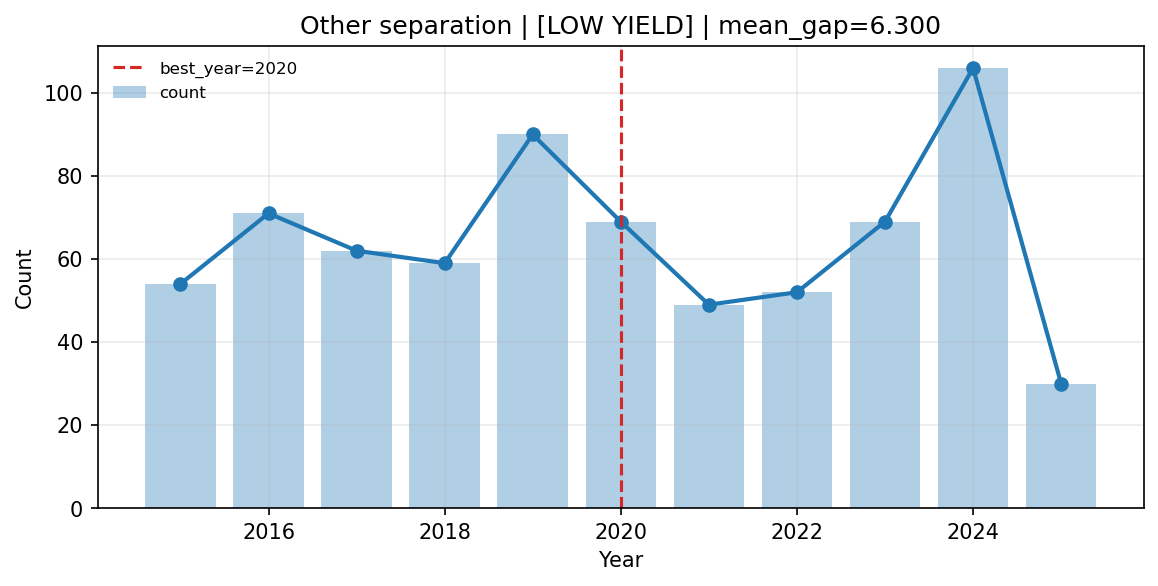

Solution distribution analysis summary:


reaction_class                                                   Other separation
problem_category                                                      [LOW YIELD]
pivot_year                                                                   2020
n_rows_matched                                                                711
n_before_rows                                                                 405
n_after_rows                                                                  306
n_solution_classes                                                             41
n_solution_classes_increased                                                   16
top_increase                    {'solution': 'optimization_of_reagent_stoichio...
dtype: object

Top 15 solution classes by increase in share after pivot:


,solutionCategory,count_before,count_after,count_total,share_before,share_after,delta_share,fold_change_count
0,optimization_of_reagent_stoichiometry,63,70,133,0.155556,0.228758,0.073203,1.109375
1,change_of_acid,1,6,7,0.002469,0.019608,0.017139,3.500000
2,solvent_change_for_reactivity,9,11,20,0.022222,0.035948,0.013725,1.200000
3,change_of_catalyst_or_ligand_identity,16,16,32,0.039506,0.052288,0.012781,1.000000
4,improved_mixing_or_impeller_design,0,3,3,0.000000,0.009804,0.009804,4.000000
5,entirely_new_route_or_step_replacement,2,4,6,0.004938,0.013072,0.008134,1.666667
6,custom_or_novel_reactor_design,5,6,11,0.012346,0.019608,0.007262,1.166667
7,protecting_group_change_or_removal,0,2,2,0.000000,0.006536,0.006536,3.000000
8,change_of_oxidant_or_oxidation_protocol,4,5,9,0.009877,0.016340,0.006463,1.200000
9,replacement_of_unstable_or_impure_reagent,3,4,7,0.007407,0.013072,0.005664,1.250000


Meaningful post-pivot increases (delta_share >= 0.03 and count_after >= 3):


,solutionCategory,count_before,count_after,count_total,share_before,share_after,delta_share,fold_change_count
0,optimization_of_reagent_stoichiometry,63,70,133,0.155556,0.228758,0.073203,1.109375


Meaningful post-pivot increases linked to exemplar source-paper reactions:


,solutionCategory,delta_share,count_before,count_after,paper_col,paper_value,reaction_col,reaction_value,exemplar_year
0,optimization_of_reagent_stoichiometry,0.073203,63,70,source_folder,op0c00538,None,None,2021


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from figure5_helper2 import (
    add_shift_exemplar_reactions,
    analyze_solution_distribution_at_pivot,
    assess_solution_increase_at_pivot,
    find_problem_split_year,
    find_shift_exemplar_reaction,
    link_solution_increases_to_exemplar_reactions,
    plot_linked_solution_increases,
    plot_problemcategory_trends,
    plot_split_entry_distribution,
    summarize_problem_split_years_all_reaction_classes,
    summarize_problem_split_years_for_reaction_class,
)

def pipe(pivot, problemList=problemList, key_shift_index=0):
    # fig, ax = plot_problemcategory_trends(
    #     pivot,
    #     reaction_class=entry,
    #     problem_categories=problemList,
    # )
    # plt.show()

    # best_year, best_score, split_stats = find_problem_split_year(
    #     pivot,
    #     reaction_class=entry,
    #     problem_category=target_problem,
    #     score_metric="mean_gap",
    #     exclude_last_year=True,
    #     min_years_before=2,
    #     min_years_after=2,
    # )
    # print(f"Best split year for '{target_problem}': {best_year} | best mean_gap={best_score:.3f}")
    # display(split_stats.sort_values("mean_gap", ascending=False).head(10))

    # all_problem_splits = summarize_problem_split_years_for_reaction_class(
    #     pivot,
    #     reaction_class=entry,
    #     problem_categories=list(problemList),
    #     score_metric="mean_gap",
    #     exclude_last_year=True,
    #     min_years_before=2,
    #     min_years_after=2,
    #     min_total_occurrences=1,
    # )
    # print(f"All-problem split summary for {entry} (top 15, mean_gap score):")
    # display(all_problem_splits.head(15))

    all_reaction_problem_splits = summarize_problem_split_years_all_reaction_classes(
        pivot,
        reaction_classes=list(rxn_class_list),
        problem_categories=list(problemList),
        score_metric="mean_gap",
        exclude_last_year=True,
        min_years_before=2,
        min_years_after=2,
        min_total_occurrences=1,
    )
    print(
        f"Full analysis complete: {len(all_reaction_problem_splits)} rows across "
        f"{all_reaction_problem_splits['reaction_class'].nunique()} reaction classes"
    )
    # print("Global top 20 splits (mean_gap):")
    # display(all_reaction_problem_splits.head(20))
    # print("Top 3 splits per reaction class (mean_gap):")
    # display(all_reaction_problem_splits.groupby("reaction_class", as_index=False).head(3).reset_index(drop=True))

    # entry_row = all_reaction_problem_splits.iloc[0]
    # fig, ax, entry_year_distribution = plot_split_entry_distribution(
    #     pivot,
    #     entry_row,
    # )
    # plt.show()
    # print("Year distribution for selected full-analysis entry:")
    # display(entry_year_distribution)

    all_reaction_problem_splits_with_exemplar = add_shift_exemplar_reactions(
        df_long,
        all_reaction_problem_splits,
    )

    print("Top 10 shift rows with exemplar paper/reaction:")
    display(
        all_reaction_problem_splits_with_exemplar[
            [
                "reaction_class",
                "problem_category",
                "best_year",
                "split_score",
                "shift_side",
                "paper_col",
                "paper_value",
                "reaction_col",
                "reaction_value",
                "year",
            ]
        ].head(10)
    )
    key_shift = all_reaction_problem_splits_with_exemplar.iloc[key_shift_index]
    key_exemplar = find_shift_exemplar_reaction(df_long, key_shift)
    print("\nKey exemplar for the top shift:")
    display(pd.Series(key_exemplar))
    fig, ax, entry_year_distribution = plot_split_entry_distribution(
        pivot,
        key_shift,
    )
    plt.show()
    # print("Year distribution for selected full-analysis entry:")
    # display(entry_year_distribution)

    solution_dist, solution_summary = analyze_solution_distribution_at_pivot(
        df_long,
        key_shift,
        solution_col="solutionCategory",
        year_col="pub_year",
        min_total_mentions=1,
    )

    print("Solution distribution analysis summary:")
    display(pd.Series(solution_summary))

    print("Top 15 solution classes by increase in share after pivot:")
    display(solution_dist.head(15))

    meaningful_increases = assess_solution_increase_at_pivot(
        solution_dist,
        solution_col="solutionCategory",
        min_delta_share=0.03,
        min_after_count=3,
    )

    print("Meaningful post-pivot increases (delta_share >= 0.03 and count_after >= 3):")
    display(meaningful_increases.head(15))

    linked_meaningful_increases = link_solution_increases_to_exemplar_reactions(
        df_long,
        key_shift,
        meaningful_increases,
        solution_col="solutionCategory",
    )

    print("Meaningful post-pivot increases linked to exemplar source-paper reactions:")
    display(
        linked_meaningful_increases[
            [
                "solutionCategory",
                "delta_share",
                "count_before",
                "count_after",
                "paper_col",
                "paper_value",
                "reaction_col",
                "reaction_value",
                "exemplar_year",
            ]
        ].head(20)
    )
    
pivot = (
    df_long
    .groupby(["reaction_class", "pub_year", "problemCategory"])
.size()
    .unstack(fill_value=0)
)

pipe(pivot=pivot, key_shift_index=1)
# if len(linked_meaningful_increases) == 0:
#     print("No linked meaningful increases available yet.")
# else:
#     fig, ax, linked_plot_df = plot_linked_solution_increases(
#         linked_meaningful_increases,
#         solution_col="solutionCategory",
#         delta_col="delta_share",
#         paper_col="paper_value",
#         top_n=10,
#     )
#     plt.show()
#     display(
#         linked_plot_df[
#             [
#                 "solutionCategory",
#                 "delta_share",
#                 "paper_value",
#                 "reaction_value",
#                 "exemplar_year",
#             ]
#         ]
    # )

In [5]:
all_reaction_class_grouped = df_long.groupby("reaction_class")

years = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
reag_year_distr = {}
reag_totals = {}
reaction_reag_year_distr = {}
reaction_year_distr = {}
reaction_year_problem = {}
reaction_year_solution = {}
reagents_to_rows = {}
reagent_alias_map = {
    "toluene (solvent)": "toluene",
    "ethanol (solvent)": "ethanol",
    "acetone (solvent)": "acetone",
    "toluene - solvent": "toluene",
    "dmso": "dimethyl sulfoxide",
    "4-dioxane": "dioxane",
    "dipea": "diisopropylethylamine",
    "nahco3": "sodium bicarbonate",
    "koh": "potassium hydroxide",
    "cs2co3": "cesium carbonate",
    "na2co3": "sodium carbonate",
    "tea": "triethylamine",
}

cooc_rows = []

for reaction_class, group_df in all_reaction_class_grouped:
    if reaction_class not in reaction_reag_year_distr:
        reaction_reag_year_distr[reaction_class] = {}
        reaction_year_distr[reaction_class] = {yr: 0 for yr in years}
        reagents_to_rows[reaction_class] = {}
        reaction_year_problem[reaction_class] = {yr: {} for yr in years}
        reaction_year_solution[reaction_class] = {yr: {} for yr in years}
        
    for _, row in group_df.iterrows():
        try:
            reagent_groups = eval(row["reagents_used_clean"])
        except Exception:
            continue
        if row["pub_year"] in reaction_year_distr[reaction_class]:
            reaction_year_distr[reaction_class][row["pub_year"]] += 1
        if row["problemCategory"] not in reaction_year_problem[reaction_class][row["pub_year"]]:
            reaction_year_problem[reaction_class][row["pub_year"]][row["problemCategory"]] = 0
        reaction_year_problem[reaction_class][row["pub_year"]][row["problemCategory"]] += 1
        if row["solutionCategory"] not in reaction_year_solution[reaction_class][row["pub_year"]]:
            reaction_year_solution[reaction_class][row["pub_year"]][row["solutionCategory"]] = 0
        reaction_year_solution[reaction_class][row["pub_year"]][row["solutionCategory"]] += 1
        for reagent_group in reagent_groups:
            for reagent in reagent_group.split(","):
                reagent = reagent_alias_map.get(reagent.strip(), reagent.strip())
                if not reagent:
                    continue
                if reagent not in reagents_to_rows[reaction_class]:
                    reagents_to_rows[reaction_class][reagent] = {yr: [] for yr in years}


                if reagent not in reag_year_distr:
                    reag_year_distr[reagent] = {yr: 0 for yr in years}
                if reagent not in reaction_reag_year_distr[reaction_class]:
                    reaction_reag_year_distr[reaction_class][reagent] = {yr: 0 for yr in years}
                if row["pub_year"] in reag_year_distr[reagent]:
                    reag_year_distr[reagent][row["pub_year"]] += 1
                if row["pub_year"] in reaction_reag_year_distr[reaction_class][reagent]:
                    reaction_reag_year_distr[reaction_class][reagent][row["pub_year"]] += 1
                reagents_to_rows[reaction_class][reagent][row["pub_year"]].append(row)

                if reagent not in reag_totals:
                    reag_totals[reagent] = 0
                reag_totals[reagent] += 1


                cooc_rows.append(
                    {
                        "reaction_class": reaction_class,
                        "reag": reagent,
                    }
                )

df_rxn_reag = pd.DataFrame(cooc_rows)

sorted_reags = sorted(reag_totals, key=lambda r: reag_totals[r], reverse=True)
for r in sorted_reags:
    print(r, reag_totals[r])

print(f"Rows for reaction_class ↔ reagent co-occurrence: {len(df_rxn_reag):,}")

null 20839
water 10688
tetrahydrofuran 4029
methanol 2818
acetonitrile 2628
hydrochloric acid 2607
toluene 2437
ethanol 2050
dichloromethane 2024
sodium hydroxide 1845
dimethylformamide 1756
nitrogen atmosphere 1731
acetic acid 1329
triethylamine 1318
ethyl acetate 1274
isopropanol 1177
potassium carbonate 1098
hydrogen gas 1003
dimethyl sulfoxide 919
palladium catalyst 918
diisopropylethylamine 915
sulfuric acid 805
heptane 793
1 787
methyl tert-butyl ether 766
acetone 764
potassium phosphate 749
2-methyltetrahydrofuran 687
pyridine 587
dioxane 560
triphenylphosphine 555
potassium hydroxide 553
palladium on carbon 543
sodium bicarbonate 518
n-methyl-2-pyrrolidone 506
hexane 480
palladium acetate 470
trifluoroacetic acid 451
sodium carbonate 424
hydrogen peroxide 423
copper catalyst 411
n-butyllithium 381
dimethylacetamide 337
ammonium chloride 321
nickel catalyst 320
methanesulfonic acid 309
dbu 305
copper iodide 295
potassium tert-butoxide 294
nitric acid 291
zinc 290
ammonia 282
arg

In [6]:
bases = ["sodium hydroxide", "triethylamine", "potassium carbonate",
         "diisopropylethylamine", "potassium phosphate", "pyridine", 
         "sodium bicarbonate", "sodium carbonate", "dbu",
         "sodium chloride", "cesium carbonate", "lithium hydroxide", "lithium diisopropylamide",
         "sodium phosphate", "6-lutidine", "potassium bicarbonate", "collidine", "potassium tert-butoxide", "tetramethylguanidine", "ammonium hydroxide",
         "trimethylamine", "TMEDA", "DABCO"]
acids = [ "acetic acid", "sulfuric acid", "trifluoroacetic acid", "nitric acid", "p-toluenesulfonic acid", "phosphoric acid", "hydrobromic acid"]
solvents = ["water", "tetrahydrofuran", "methanol", "acetonitrile", "dichloromethane",
            "toluene", "ethanol", "dimethylformamide", "ethyl acetate", "isopropanol", "chloroform",
            "dimethyl sulfoxide", "heptane", "acetone", "hexane", "dimethylacetamide",
            "diethyl ether", "benzene", "dioxane", "n-methyl-2-pyrrolidone", "2-methyltetrahydrofuran", "methyl tert-butyl ether", "4-dioxane"]

print(len(bases), len(solvents))

23 23


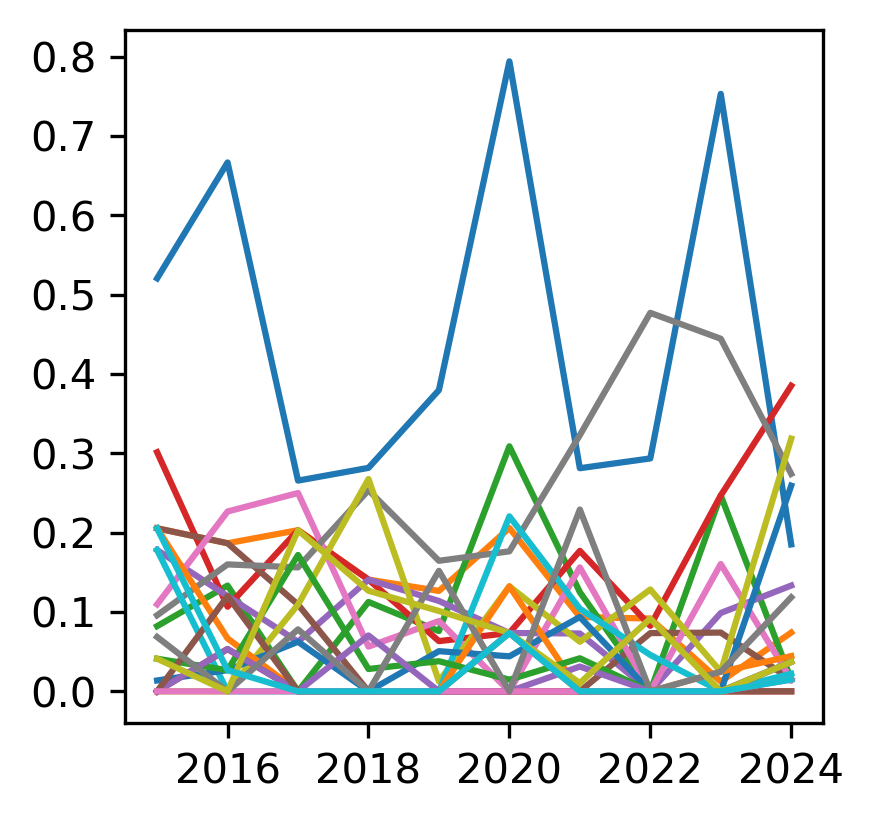

In [7]:
import matplotlib.pyplot as plt
solvents = ["water", "tetrahydrofuran", "methanol", "acetonitrile", "dichloromethane",
            "toluene", "ethanol", "dimethylformamide", "ethyl acetate", "isopropanol", "chloroform",
            "dimethyl sulfoxide", "heptane", "acetone", "hexane", "dimethylacetamide",
            "diethyl ether", "benzene", "dioxane", "n-methyl-2-pyrrolidone", "2-methyltetrahydrofuran", "methyl tert-butyl ether", "4-dioxane"]

fig,ax = plt.subplots(figsize=(3,3), dpi=300)
plt.rcParams["font.size"] = 6
plt.rcParams["font.family"] = "sans-serif"
tclass = "Carboxylic acid + amine condensation"
for s in solvents:
    xs = years[1:-1]
    if s not in reaction_reag_year_distr[tclass]:
        continue
    ys = [reaction_reag_year_distr[tclass][s][yr]/reaction_year_distr[tclass][yr] for yr in xs]
    ax.plot(xs, ys, label=s)
    # print(reag_year_distr[s])


46 23 23
['Carboxylic acid + amine condensation', 'Bromo Suzuki coupling', 'Amide Schotten-Baumann', 'SNAr ether synthesis', 'Esterification', 'Ring closing olefin metathesis', 'Ester hydrolysis', 'N-Boc deprotection', 'Nitro to amino', 'Ketone to alcohol reduction', 'Alkene hydrogenation', 'Acid to acid chloride', 'Bromo Buchwald-Hartwig amination', 'Chlorination', 'Bromination', 'Hydroamination', 'Carbamate Schotten-Baumann', 'Alcohol to aldehyde oxidation', 'Bromo N-alkylation', 'Aldehyde reductive amination', 'Carboxylic acid to acid chloride', 'Racemization', 'Bromo Suzuki-type coupling', 'Bromo Sonogashira coupling']


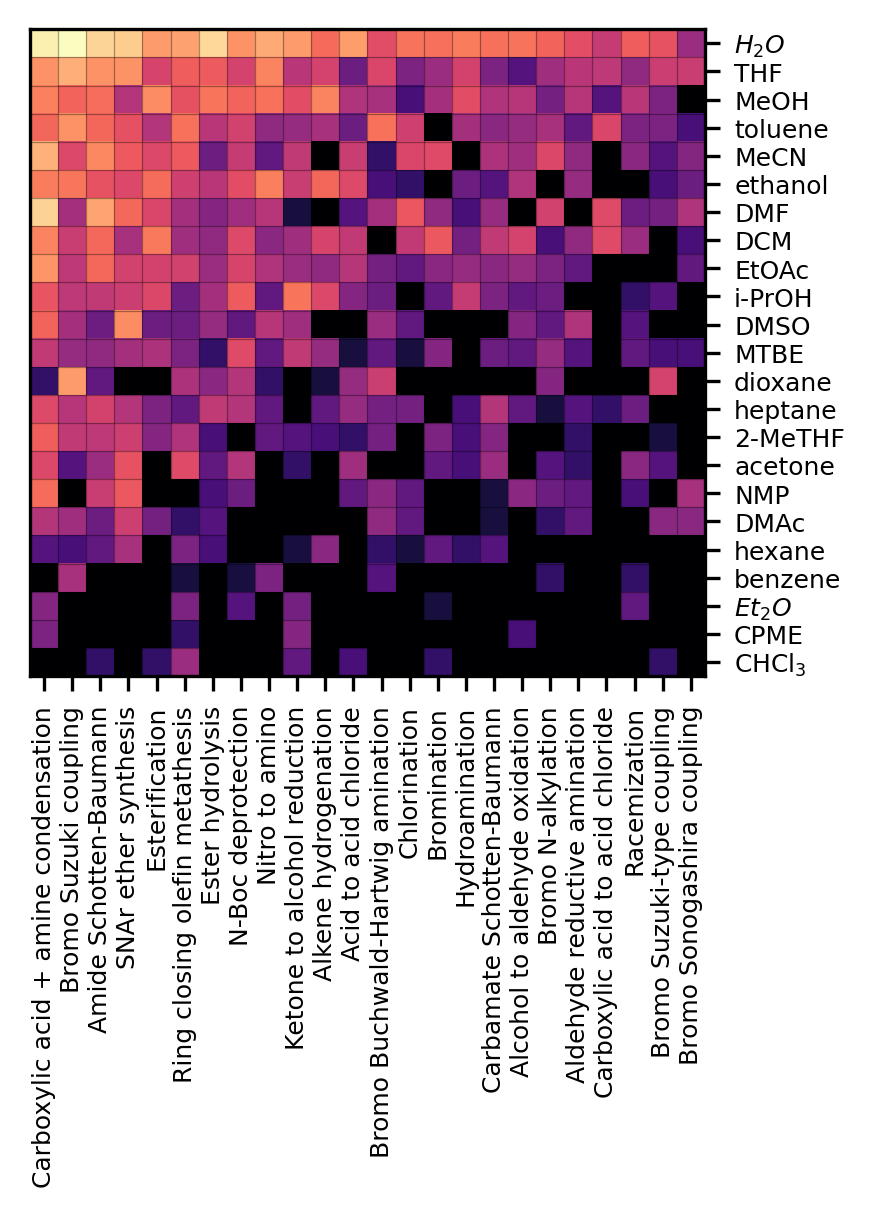

In [12]:
def save_cooccurrence_matrix(
    df,
    col_a,
    col_b,
    *,
    normalize=None,
    min_count=1.0,
    top_n=None,
    sort_by="frequency",
    figsize=(3.2, 2.8),
    cmap="copper",
    log_scale=False,
    matrix_save_path=None,
    fig_save_path=None,
    title=None,
    use_pretty_labels=True,
    row_order=None,
    cbar=False
):
    """
    Build and save a co-occurrence matrix between any two columns.

    Parameters
    ----------
    df : pd.DataFrame
    col_a, col_b : str
        Column names for rows/columns in the co-occurrence matrix.
    normalize : {None, 'all', 'index', 'columns'}
        Passed to pd.crosstab(normalize=...).
    min_count : int
        Drop row/column labels whose total count is below this threshold.
    top_n : int | None
        Keep only the top-N row/column labels by raw frequency before plotting.
    sort_by : {'frequency', 'alphabetical'}
        How to order labels on each axis.
    figsize : tuple
        Matplotlib figure size.
    cmap : str
        Colormap for heatmap.
    log_scale : bool
        If True, display colors on a log1p scale while keeping colorbar labels in original units.
    matrix_save_path : str | None
        If provided, save matrix to CSV.
    fig_save_path : str | None
        If provided, save heatmap figure.
    title : str | None
        Custom title; default uses column names.
    use_pretty_labels : bool
        If True and pretty_label exists, prettify tick labels.
    row_order : list[str] | None
        If provided, keep only these row labels and order rows accordingly.

    Returns
    -------
    matrix : pd.DataFrame
    fig, ax : matplotlib Figure/Axes
    """
    required = {col_a, col_b}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    if top_n is not None:
        if not isinstance(top_n, int) or top_n < 1:
            raise ValueError("top_n must be a positive integer or None")

    da_counts = df[col_a].value_counts()
    db_counts = df[col_b].value_counts()
    to_remove = []
    for idx, i in zip(da_counts.index, da_counts):
        if i < min_count:
            to_remove.append(idx)
    for idx, i in zip(db_counts.index, db_counts):
        if i < min_count:
            to_remove.append(idx)
    d = df[[col_a, col_b]]
    d = d[~d[col_a].isin(to_remove) & ~d[col_b].isin(to_remove)].copy()
    d = d.dropna().copy()
    d = d[d[col_b] != "Unrecognized"]
    d = d[d[col_b] != "Other separation"]

    if len(d) == 0:
        raise ValueError("No non-null rows available for selected columns.")

    matrix_unorm = pd.crosstab(
        d[col_a].astype(str),
        d[col_b].astype(str),
        normalize=False,
    )
    matrix = pd.crosstab(
        d[col_a].astype(str),
        d[col_b].astype(str),
        normalize=normalize,
    )
    if min_count > 0:
        if normalize is not None:
            norm_val = normalize_value(min_count, matrix_unorm, normalize=normalize)
            print(min_count, "->", norm_val)
            row_totals = matrix.sum(axis=1)
            col_totals = matrix.sum(axis=0)
            matrix = matrix.loc[row_totals >= norm_val, col_totals >= norm_val]
        else:
            row_totals = matrix.sum(axis=1)
            col_totals = matrix.sum(axis=0)
            matrix = matrix.loc[row_totals >= min_count, col_totals >= min_count]

    if row_order is not None:
        row_order = [r for r in row_order if r in matrix.index]
        matrix = matrix.loc[row_order]

    if top_n is not None:
        row_rank = matrix_unorm.sum(axis=1).sort_values(ascending=False).index.tolist()
        col_rank = matrix_unorm.sum(axis=0).sort_values(ascending=False).index.tolist()
        top_rows = [r for r in row_rank if r in matrix.index][:top_n]
        top_cols = [c for c in col_rank if c in matrix.columns][:top_n]
        matrix = matrix.loc[top_rows, top_cols]

    if sort_by == "frequency":
        if row_order is None:
            matrix = matrix.loc[matrix.sum(axis=1).sort_values(ascending=False).index]
        matrix = matrix.loc[:, matrix.sum(axis=0).sort_values(ascending=False).index]
    elif sort_by == "alphabetical":
        if row_order is None:
            matrix = matrix.sort_index(axis=0)
        matrix = matrix.sort_index(axis=1)
    else:
        raise ValueError("sort_by must be one of: 'frequency', 'alphabetical'")

    if matrix.shape[0] == 0 or matrix.shape[1] == 0:
        raise ValueError("No data left after min_count/top_n filtering.")

    if matrix_save_path is not None:
        matrix.to_csv(matrix_save_path)

    with plt.rc_context(
        {
            "font.size": 6,
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial"],
        }
    ):
        fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=300)

        values = matrix.to_numpy(dtype=float)
        # print(np.max(values))
        # print(np.max(values))
        plot_values = np.log1p(values) if log_scale else values
        im = ax.imshow(plot_values, aspect="equal", cmap=cmap)

        ax.set_xticks(np.arange(matrix.shape[1]))
        ax.set_yticks(np.arange(matrix.shape[0]))

        if "reverse_rxn_code_lookup" in globals():
            reverse_rxn_code_lookup["Acid to acid chloride"] = "9.3.2"

        x_labels = matrix.columns.tolist()
        y_labels = matrix.index.tolist()
        if use_pretty_labels and "pretty_label" in globals() and col_b == "reaction_class" and "reverse_rxn_code_lookup" in globals():
            x_labels = [reverse_rxn_code_lookup[v] for v in x_labels]
            y_labels = [pretty_rxn_label(pretty_label(v)) for v in y_labels]
            
        print(x_labels)

        ax.set_xticklabels(x_labels, rotation=90, ha="center")
        ax.set_yticklabels([label_map[yy] for yy in y_labels])

        ax.set_xticks(np.arange(-0.5, matrix.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, matrix.shape[0], 1), minor=True)
        ax.grid(which="minor", color="black", linestyle="-", linewidth=0.3, alpha=0.35)
        ax.tick_params(which="minor", bottom=False, left=False)

        ax.yaxis.tick_right()
        ax.tick_params(axis="y", which="major", left=False, right=True, labelleft=False, labelright=True)
        ax.tick_params(axis="y", which="minor", left=False, right=False, labelleft=False, labelright=False)
        if cbar:
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if fig_save_path is not None:
            fig.savefig(
                fig_save_path,
                dpi=300,
                bbox_inches="tight",
                pad_inches=0.01,
            )

    return matrix, fig, ax


# Example usage:
import os
import numpy as np

os.makedirs("figout", exist_ok=True)

target_reagent_rows = [
    "water",
    "tetrahydrofuran",
    "methanol",
    "acetonitrile",
    "dichloromethane",
    "toluene",
    "ethanol",
    "dimethylformamide",
    "ethyl acetate",
    "isopropanol",
    "dimethyl sulfoxide",
    "heptane",
    "acetone",
    "hexane",
    "dimethylacetamide",
    "diethyl ether",
    "benzene",
    "dioxane",
    "2-methyltetrahydrofuran",
    "n-methyl-2-pyrrolidone",
    "methyl tert-butyl ether"
]


bases = ["sodium hydroxide", "triethylamine", "potassium carbonate",
         "diisopropylethylamine", "potassium phosphate", "pyridine", 
         "sodium bicarbonate", "sodium carbonate", "dbu",
         "sodium chloride", "cesium carbonate", "lithium hydroxide", "lithium diisopropylamide",
         "sodium phosphate", "6-lutidine", "potassium bicarbonate", "collidine", "potassium tert-butoxide", "tetramethylguanidine", "ammonium hydroxide",
         "trimethylamine", "TMEDA", "DABCO"]
acids = [ "acetic acid", "sulfuric acid", "trifluoroacetic acid", "nitric acid", "p-toluenesulfonic acid", "phosphoric acid", "hydrobromic acid"]
target_reagent_rows = ["water", "tetrahydrofuran", "methanol", "acetonitrile", "dichloromethane",
            "toluene", "ethanol", "dimethylformamide", "ethyl acetate", "isopropanol", "chloroform",
            "dimethyl sulfoxide", "heptane", "acetone", "hexane", "dimethylacetamide",
            "diethyl ether", "benzene", "dioxane", "n-methyl-2-pyrrolidone", "2-methyltetrahydrofuran", "methyl tert-butyl ether", "cyclopentyl methyl ether"]

label_map = {
    "tetrahydrofuran": "THF",
    "dimethylformamide": "DMF",
    "dimethyl sulfoxide": "DMSO",
    "dimethylacetamide": "DMAc",
    "diethyl ether": r"$Et_{2}O$",
    "dichloromethane": "DCM",
    "acetonitrile": "MeCN",
    "isopropanol": "i-PrOH",
    "ethyl acetate": "EtOAc",
    "heptane": "heptane",
    "acetone": "acetone",
    "hexane": "hexane",
    "water": r"$H_{2}O$",
    "toluene": "toluene",
    "ethanol": "ethanol",
    "benzene": "benzene",
    "dioxane": "dioxane",
    "methanol": "MeOH",
    "chloroform": "CHCl$_{3}$",
    "2-methyltetrahydrofuran": "2-MeTHF",
    "n-methyl-2-pyrrolidone": "NMP",
    "methyl tert-butyl ether": "MTBE",
    "sodium hydroxide": "NaOH",
    "triethylamine": "TEA",
    "potassium carbonate": r"$K_{2}CO_{3}$",
    "diisopropylethylamine": "DIPEA",
    "potassium phosphate": r"$K_{3}PO_{4}$",
    "pyridine": "pyridine",
    "sodium bicarbonate": r"$NaHCO_{3}$",
    "sodium carbonate": r"$Na_{2}CO_{3}$",
    "dbu": "DBU",
    "sodium chloride": "NaCl",
    "cesium carbonate": r"$Cs_{2}CO_{3}$",
    "lithium hydroxide": "LiOH",
    "sodium phosphate": r"$Na_{3}PO_{4}$",
    "6-lutidine": "6-lutidine",
    "potassium bicarbonate": r"$KHCO_{3}$",
    "collidine": "collidine",
    "trimethylamine": "TMA",
    "lithium diisopropylamide": "LDA",
    "potassium tert-butoxide": r"$t$-BuOK",
    "tetramethylguanidine": "TMG",
    "cyclopentyl methyl ether": "CPME",
    "ammonium hydroxide": "NH$_{4}$OH",
    "DABCO": "DABCO",
    "TMEDA": "TMEDA",
    
}
print(len(label_map), len(bases), len(target_reagent_rows))
cooc, fig, ax = save_cooccurrence_matrix(
    df_rxn_reag,
    "reag",
    "reaction_class",
    min_count=0,
    top_n=24,
    cmap="magma",
    normalize=False,
    log_scale=True,
    sort_by="frequency",
    matrix_save_path="figout/reagent_targets_vs_reaction_class_cooccurrence.csv",
    # fig_save_path=None,
    fig_save_path="figout/reagent_targets_vs_reaction_class_cooccurrence.png",
    use_pretty_labels=False,
    row_order=target_reagent_rows,
)

In [9]:
print(cooc)

reaction_class            Carboxylic acid + amine condensation  \
reag                                                             
water                                                      361   
tetrahydrofuran                                            107   
methanol                                                    85   
toluene                                                     61   
acetonitrile                                               161   
ethanol                                                     82   
dimethylformamide                                          244   
dichloromethane                                             90   
ethyl acetate                                              111   
isopropanol                                                 46   
dimethyl sulfoxide                                          58   
methyl tert-butyl ether                                     24   
dioxane                                                      2   
heptane   

['Carboxylic acid + amine condensation', 'Bromo Suzuki coupling', 'SNAr ether synthesis', 'Amide Schotten-Baumann', 'Ester hydrolysis', 'Esterification', 'Ring closing olefin metathesis', 'Bromo Buchwald-Hartwig amination', 'Bromo N-alkylation', 'Ketone to alcohol reduction', 'Carbamate Schotten-Baumann', 'Racemization', 'Acid to acid chloride', 'Hydroamination', 'Bromo Suzuki-type coupling', 'Bromo Sonogashira coupling', 'Alcohol to aldehyde oxidation', 'Nitro to amino', 'Bromination', 'Chlorination', 'N-Boc deprotection', 'Alkene hydrogenation', 'Carboxylic acid to acid chloride', 'Aldehyde reductive amination']
reaction_class            Carboxylic acid + amine condensation  \
reag                                                             
sodium hydroxide                                            37   
triethylamine                                              107   
potassium carbonate                                         18   
diisopropylethylamine                           

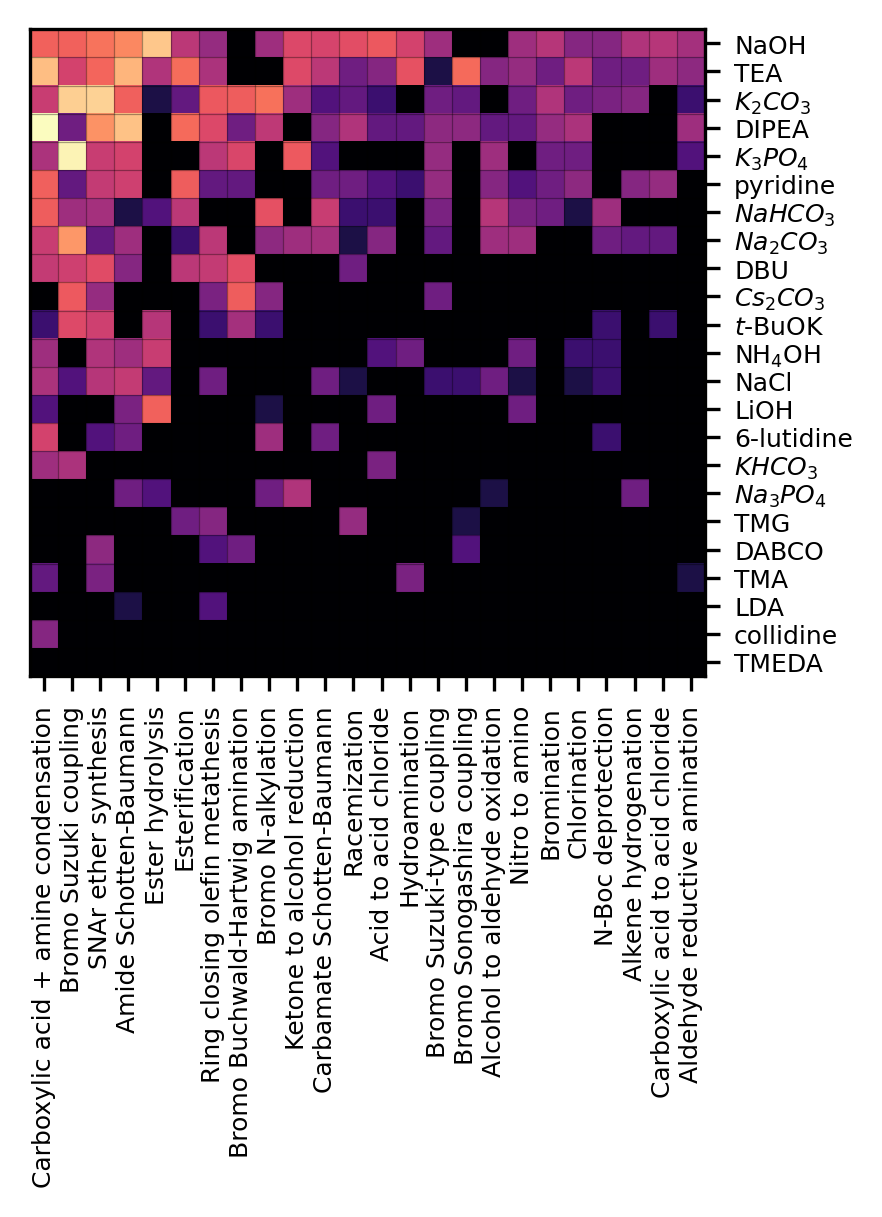

In [11]:
cooc, fig, ax = save_cooccurrence_matrix(
    df_rxn_reag,
    "reag",
    "reaction_class",
    min_count=0,
    top_n=24,
    cmap="magma",
    normalize=False,
    log_scale=True,
    sort_by="frequency",
    matrix_save_path="figout/base_targets_vs_reaction_class_cooccurrence.csv",
    # fig_save_path=None,
    fig_save_path="figout/base_targets_vs_reaction_class_cooccurrence.png",
    use_pretty_labels=False,
    row_order=bases,
    cbar=False
)
print(cooc)

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
water,38.0,50.0,17.0,20.0,30.0,54.0,27.0,32.0,61.0,25.0
tetrahydrofuran,15.0,14.0,13.0,10.0,10.0,14.0,9.0,10.0,1.0,10.0
methanol,6.0,10.0,0.0,8.0,6.0,21.0,12.0,0.0,20.0,2.0
acetonitrile,22.0,8.0,13.0,10.0,5.0,5.0,17.0,9.0,20.0,52.0
dichloromethane,13.0,9.0,4.0,10.0,9.0,5.0,7.0,0.0,8.0,18.0
toluene,15.0,14.0,7.0,0.0,0.0,5.0,0.0,8.0,6.0,2.0
ethanol,8.0,17.0,16.0,4.0,7.0,0.0,15.0,0.0,13.0,2.0
dimethylformamide,7.0,12.0,10.0,18.0,13.0,12.0,31.0,52.0,36.0,37.0
ethyl acetate,0.0,0.0,7.0,19.0,1.0,9.0,6.0,14.0,2.0,43.0
isopropanol,13.0,0.0,0.0,0.0,0.0,15.0,10.0,5.0,0.0,3.0


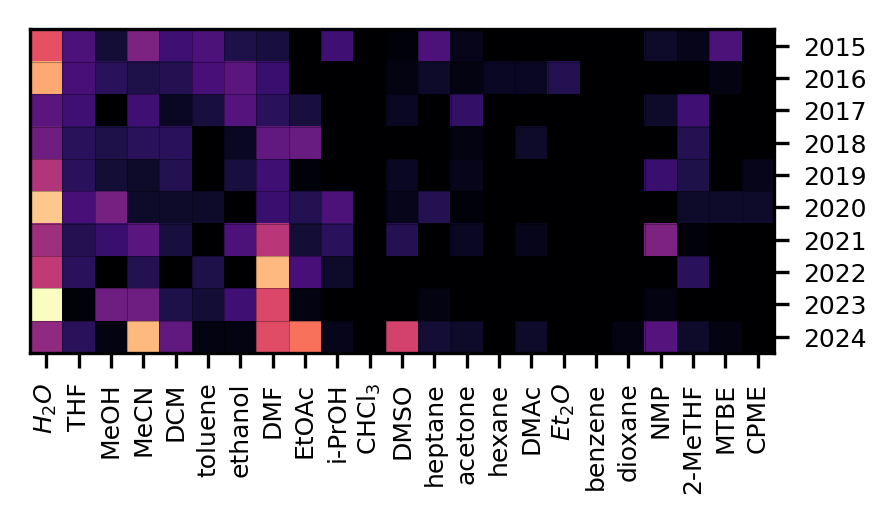

In [13]:
# Year × target reagent co-occurrence heatmap for a target reaction class

target_reaction_class = "Carboxylic acid + amine condensation"
normalize_by_reaction_year = False  # Set True to show per-year reagent share within target reaction class

if target_reaction_class not in reaction_reag_year_distr:
    raise ValueError(f"target_reaction_class not found: {target_reaction_class}")

target_years = [yr for yr in years if yr in reaction_year_distr[target_reaction_class] and yr not in [2014, 2025]]

heatmap_df = pd.DataFrame(
    0.0,
    index=target_reagent_rows,
    columns=target_years,
)

for reagent in target_reagent_rows:
    reagent_year_counts = reaction_reag_year_distr[target_reaction_class].get(reagent, {})
    for yr in target_years:
        value = reagent_year_counts.get(yr, 0)
        if normalize_by_reaction_year:
            denom = reaction_year_distr[target_reaction_class].get(yr, 0)
            value = (value / denom) if denom > 0 else 0.0
        heatmap_df.loc[reagent, yr] = value

with plt.rc_context({
    "font.size": 6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
}):
    fig, ax = plt.subplots(figsize=(3.2, 2.8), dpi=300)
    im = ax.imshow(heatmap_df.values.T, aspect="equal", cmap="magma")

    ax.set_yticks(np.arange(len(target_years)))
    ax.set_xticks(np.arange(len(target_reagent_rows)))
    ax.set_yticklabels(target_years)
    ax.set_xticklabels([label_map.get(r, r) for r in target_reagent_rows], rotation=90)

    ax.set_yticks(np.arange(-0.5, len(target_years), 1), minor=True)
    ax.set_xticks(np.arange(-0.5, len(target_reagent_rows), 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.25, alpha=0.3)
    ax.tick_params(which="minor", bottom=False, left=False)
    # cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.yaxis.tick_right()
    ax.tick_params(axis="x", which="major", left=False, right=True, labelleft=False, labelright=True)
    ax.tick_params(axis="x", which="minor", left=False, right=False, labelleft=False, labelright=False)
    ax.tick_params(axis="y", which="minor", left=False, right=False, labelleft=False, labelright=False)

    mode_label = "share" if normalize_by_reaction_year else "count"
    # ax.set_title(f"{target_reaction_class} | year vs target reagents ({mode_label})", pad=4)

    os.makedirs("figout", exist_ok=True)
    fig.savefig(
        f"figout/{target_reaction_class.replace(' ', '_').replace('+', 'plus')}_year_vs_target_reagents_heatmap_{mode_label}.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.01,
    )

display(heatmap_df)

In [13]:
print(heatmap_df)

                          2015  2016  2017  2018  2019  2020  2021  2022  \
water                     38.0  50.0  17.0  20.0  30.0  54.0  27.0  32.0   
tetrahydrofuran           15.0  14.0  13.0  10.0  10.0  14.0   9.0  10.0   
methanol                   6.0  10.0   0.0   8.0   6.0  21.0  12.0   0.0   
acetonitrile              22.0   8.0  13.0  10.0   5.0   5.0  17.0   9.0   
dichloromethane           13.0   9.0   4.0  10.0   9.0   5.0   7.0   0.0   
toluene                   15.0  14.0   7.0   0.0   0.0   5.0   0.0   8.0   
ethanol                    8.0  17.0  16.0   4.0   7.0   0.0  15.0   0.0   
dimethylformamide          7.0  12.0  10.0  18.0  13.0  12.0  31.0  52.0   
ethyl acetate              0.0   0.0   7.0  19.0   1.0   9.0   6.0  14.0   
isopropanol               13.0   0.0   0.0   0.0   0.0  15.0  10.0   5.0   
chloroform                 0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
dimethyl sulfoxide         1.0   2.0   4.0   0.0   4.0   3.0   9.0   0.0   
heptane     

In [44]:
for r in reagents_to_rows[target_reaction_class]["dimethylformamide"]:
    print(r, len(reagents_to_rows[target_reaction_class]["dimethylformamide"][r]))

2014 0
2015 7
2016 12
2017 10
2018 18
2019 13
2020 12
2021 31
2022 52
2023 36
2024 37
2025 16


In [100]:
for problem in solutionList:
    xs = []
    ys = []
    for yr in reaction_year_solution[target_reaction_class]:
        if yr in [2014, 2025]:  continue
        if problem in reaction_year_solution[target_reaction_class][yr]:
            xs.append(yr)
            ys.append(reaction_year_solution[target_reaction_class][yr][problem])
            # print(reaction_year_solution[target_reaction_class][yr][problem])
    # plt.plot(xs, ys, label=problem)
    # plt.legend()
            # print(r, reaction_year_problem[target_reaction_class][yr][r])
for problem in problemList:
    print(problem)
    for r in reagents_to_rows[target_reaction_class]["dimethylformamide"][2022]:
        if r["problemCategory"] == problem:
            if r["solutionCategory"] == "solvent_change_for_reactivity":
                print(r["problemDescription"])
                print(r["solutionDescription"])
                print(r["source_folder"])
    print()


[LOW YIELD]
Some HBTU‑mediated runs (especially in neat DMF) showed incomplete conversion, leaving residual starting material.
Using a DMF/toluene (1:1) solvent system increased the coupling rate and gave quantitative conversion.
op2c00144

[PURIFICATION]

[MIXABILITY]

[SOLUBILITY]

[DECOMPOSITION]

[VARIABILITY]

[COST]

[EXOTHERMIC]

[SAFETY]

[LONG_REACTIONS]

[AVAILABILITY]



In [145]:
print(df_long.columns)
print(len(df_long.source_folder.unique()))
print(len(df_long))

paper_group = df_long.groupby("source_folder")
n = 0
for i,k in paper_group:
    n += len(k.description.unique())
    
print(n, len(df_long.description.unique()))
print(n, len(df_long.rxnCode.unique()), len(df_long.solutionCategory.unique()), len(df_long.problemCategory.unique()))

Index(['Unnamed: 0', 'reaction_class', 'description', 'reagents_used',
       'confidence', 'reasoning', 'pub_year', 'source_folder', 'rxnCategory',
       'rxnSubcategory', 'rxnCode', 'problemCategory', 'problemDescription',
       'solutionCategory', 'solutionDescription', 'solutionCat_L1',
       'solutionCat_L2', 'reagents_used_clean', 'n_reagents_clean'],
      dtype='object')
1956
21878
7481 7481
7481 302 55 11
